In [23]:
import os, json, joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from collections import defaultdict
from typing import Dict, List,Tuple, Any, Optional
import math
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import preprocess as pp
import DTC_Config
print("TF version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TF version: 2.10.0
Num GPUs Available: 1


In [2]:
def load_vehicle_csv(path: str, cfg: DTC_Config.Config) -> pd.DataFrame:
    df = pd.read_csv(path)
    current_target = "DTC"
    time_col = df.iloc[:, 0]
    ts = pp.parse_timestamp(time_col, cfg.timestamp_format_try)

    df = df.drop(df.columns[0], axis=1).copy()
    df.insert(0, "timestamp", ts)
    if current_target not in df.columns:
        raise ValueError(f"Missing target column '{current_target}' in {path}")
    df[cfg.target] = df[current_target].apply(lambda x: 0 if str(x).strip() == "0" else 1).astype(int)

    df["vehicle_id"] = os.path.splitext(os.path.basename(path))[0].replace("_user", "")
    return df

In [3]:
def load_all(cfg: DTC_Config.Config) -> pd.DataFrame:
    frames: List[pd.DataFrame] = []
    for f in cfg.files:
        p = os.path.join(cfg.data_dir, f)
        
        if not os.path.exists(p):
            print(f"  File not found, skipping.")
            continue
        frames.append(load_vehicle_csv(p, cfg))
    if not frames:
        raise FileNotFoundError("No dataset files found. Check cfg.data_dir and cfg.files.")

    df = pd.concat(frames, ignore_index=True)
    df = df.dropna(subset=["timestamp"]).sort_values(["vehicle_id", "timestamp"]).reset_index(drop=True)
    df = df.drop(columns=["DTC"], errors="ignore")
    return df

In [4]:
def split_train_val_test_per_vehicle(
    df: pd.DataFrame, test_ratio_last: float, val_ratio_last: float
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    trains, vals, tests = [], [], []
    for g in df.groupby("vehicle_id", sort=False):
        g = g[1].sort_values("timestamp")
        n = len(g)
        n_test = max(1, int(n * test_ratio_last))
        test = g.iloc[-n_test:]
        remain = g.iloc[: n - n_test]
        n_val = max(1, int(len(remain) * val_ratio_last))
        val = remain.iloc[-n_val:]
        train = remain.iloc[: len(remain) - n_val]
        if len(train) < 2:
            continue
        trains.append(train)
        vals.append(val)
        tests.append(test)
    return pd.concat(trains), pd.concat(vals), pd.concat(tests)

In [5]:
def compute_class_weights(y: np.ndarray) -> Dict[int, float]:
    pos = y.sum()
    neg = len(y) - pos
    if pos == 0 or neg == 0:
        return {0: 1.0, 1: 1.0}
    w_pos = neg / max(1.0, pos)
    w_neg = 1.0
    return {0: w_neg, 1: w_pos}

In [6]:
def _safe_get(h, k):
    return h[k] if k in h else None

def plot_training_curves(history):
    h = history.history  
    
    def f1(p, r):
        return [ (2*pp*rr)/(pp+rr+1e-12) if (pp is not None and rr is not None and (pp+rr)>0) else math.nan
                 for pp, rr in zip(p or [], r or []) ]

    train_prec,  val_prec  = _safe_get(h, "precision"),   _safe_get(h, "val_precision")
    train_rec,   val_rec   = _safe_get(h, "recall"),      _safe_get(h, "val_recall")
    train_f1 = f1(train_prec, train_rec) if train_prec and train_rec else None
    val_f1   = f1(val_prec, val_rec)     if val_prec and val_rec     else None

    charts = [
        ("loss",        "val_loss",        "Loss"),
        ("pr_auc",      "val_pr_auc",      "PR AUC"),
        ("roc_auc",     "val_roc_auc",     "ROC AUC"),
        ("precision",   "val_precision",   "Precision"),
        ("recall",      "val_recall",      "Recall"),
    ]

    for train_k, val_k, title in charts:
        if train_k in h or val_k in h:
            plt.figure()
            if train_k in h: plt.plot(h[train_k], label=f"train_{train_k}")
            if val_k   in h: plt.plot(h[val_k],   label=f"val_{train_k}")
            plt.title(title); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)
            plt.show()

    if train_f1 or val_f1:
        plt.figure()
        if train_f1: plt.plot(train_f1, label="train_f1")
        if val_f1:   plt.plot(val_f1,   label="val_f1")
        plt.title("F1 (derived from precision/recall)"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)
        plt.show()

In [7]:
def plot_test_curves(
    y_true,
    y_prob,
    threshold=0.5,
    title_suffix=" (test)",
    cfg=None,
    *,
    normalize_cm: bool = True,
    dpi: int = 120,
):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    if y_true.size == 0 or y_prob.size == 0:
        raise ValueError("plot_test_curves: empty inputs.")
    if y_true.shape[0] != y_prob.shape[0]:
        raise ValueError(f"Length mismatch: y_true={y_true.shape[0]}, y_prob={y_prob.shape[0]}")

    out_dir = getattr(cfg, "model_dir", None) if cfg is not None else None
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    assets = {}
    metrics = {}

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    metrics["roc_auc_curve"] = float(roc_auc_val)

    plt.figure(dpi=dpi)
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Random")
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title("ROC" + title_suffix)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(); plt.grid(True)
    if out_dir:
        roc_path = os.path.join(out_dir, "roc_curve.png")
        plt.savefig(roc_path, bbox_inches="tight")
        assets["roc_curve"] = roc_path
    plt.show(); plt.close()

    # PR
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    pr_auc_curve = auc(rec, prec) 
    ap_score = average_precision_score(y_true, y_prob) 
    metrics["pr_auc_curve"] = float(pr_auc_curve)
    metrics["average_precision"] = float(ap_score)

    prevalence = (y_true == 1).mean()
    plt.figure(dpi=dpi)
    plt.plot(rec, prec, label=f"PR AUC = {pr_auc_curve:.3f} | AP = {ap_score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyles="--", linewidth=1, label=f"Baseline (pos={prevalence:.3f})")
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title("Precision–Recall" + title_suffix)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(); plt.grid(True)
    if out_dir:
        pr_path = os.path.join(out_dir, "pr_curve.png")
        plt.savefig(pr_path, bbox_inches="tight")
        assets["pr_curve"] = pr_path
    plt.show(); plt.close()

    y_hat = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    if normalize_cm:
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_disp = cm_norm
        fmt = ".2f"
        title = f"Confusion Matrix (normalized, thr={threshold:.3f})"
    else:
        cm_disp = cm
        fmt = "d"
        title = f"Confusion Matrix (thr={threshold:.3f})"

    metrics["threshold"] = float(threshold)
    metrics["cm"] = cm.tolist()

    plt.figure(dpi=dpi)
    plt.imshow(cm_disp, interpolation="nearest")
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    tick_labels = ["0", "1"]
    plt.xticks([0, 1], tick_labels); plt.yticks([0, 1], tick_labels)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, format(cm_disp[i, j], fmt), ha="center", va="center")
    plt.colorbar(); plt.tight_layout()
    if out_dir:
        cm_path = os.path.join(out_dir, "confusion_matrix.png")
        plt.savefig(cm_path, bbox_inches="tight")
        assets["confusion_matrix"] = cm_path
    plt.show(); plt.close()

    return {"metrics": metrics, "assets": assets}

In [8]:
def export_pipeline(
    cfg,
    model: tf.keras.Model,
    scaler_bundle: Dict[str, Any],
    *,
    threshold: float = 0.5
) -> Dict[str, str]:
    os.makedirs(cfg.model_dir, exist_ok=True)

    model_path = os.path.join(cfg.model_dir, f"{cfg.model_name}.keras")
    model.save(model_path)  # tf 2.12+ native format

    bundle_path = os.path.join(cfg.model_dir, cfg.scaler_name) 
    joblib.dump(scaler_bundle, bundle_path)

    cfg_path = os.path.join(cfg.model_dir, cfg.config_name)
    with open(cfg_path, "w", encoding="utf-8") as f:
        json.dump(cfg.__dict__, f, indent=2)

    manifest = {
        "model_path": model_path,
        "bundle_path": bundle_path,
        "config_path": cfg_path,
        "threshold": float(threshold),
        "seq_len": int(scaler_bundle["seq_len"]) if "seq_len" in scaler_bundle else int(cfg.seq_len),
        "horizon": int(scaler_bundle["horizon"]) if "horizon" in scaler_bundle else int(cfg.horizon),
        "features": scaler_bundle.get("features", []),
        "group_col": scaler_bundle.get("group_col", "vehicle_id"),
        "masked_flags": scaler_bundle.get("masked_flags", {}),
        "policy": scaler_bundle.get("policy", {}),
        "versions": {
            "tf": tf.__version__,
            "model_version": getattr(cfg, "version", "v1"),
        },
    }
    manifest_path = os.path.join(cfg.model_dir, "manifest.json")
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    return {"model_path": model_path, "bundle_path": bundle_path, "manifest_path": manifest_path}

In [9]:
def train_and_eval(cfg: DTC_Config.Config):
    os.makedirs(cfg.model_dir, exist_ok=True)

    df = load_all(cfg)
    feats = pp.infer_features(df, cfg)

    train_df, val_df, test_df = split_train_val_test_per_vehicle(
        df, cfg.test_ratio_last, cfg.val_ratio_last
    )

    scaler = pp.fit_scaler(train_df, feats, group_col="vehicle_id")

    scaler["features"] = list(feats)
    scaler["seq_len"]  = int(cfg.seq_len)
    scaler["horizon"]  = int(cfg.horizon)
    scaler["group_col"] = "vehicle_id"

    train_df = pp.transform(train_df, scaler)
    val_df   = pp.transform(val_df, scaler)
    test_df  = pp.transform(test_df, scaler)

    X_train, y_train = pp.make_windows(train_df, feats, cfg.target, cfg.seq_len, cfg.horizon, cfg.stride)
    X_val,   y_val   = pp.make_windows(val_df,   feats, cfg.target, cfg.seq_len, cfg.horizon, cfg.stride)
    X_test,  y_test  = pp.make_windows(test_df,  feats, cfg.target, cfg.seq_len, cfg.horizon, cfg.stride)

    if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
        raise RuntimeError("Windowing produced empty datasets. Check seq_len/horizon/ratios.")

    ds_train = pp.make_tf_dataset(X_train, y_train, cfg.batch_size, shuffle=True)
    ds_val   = pp.make_tf_dataset(X_val,   y_val,   cfg.batch_size, shuffle=False)
    ds_test  = pp.make_tf_dataset(X_test,  y_test,  cfg.batch_size, shuffle=False)

    model = pp.build_model(cfg.seq_len, len(feats), cfg)
    model.compile(
        optimizer=cfg.optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="val_pr_auc"),
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        ],
    )

    best_path = os.path.join(cfg.model_dir, f"{cfg.model_name}.keras")
    cbs = [
        callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5),
        callbacks.ModelCheckpoint(
            filepath=best_path,
            monitor="val_pr_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=False,   
        ),
    ]

    class_weights = compute_class_weights(y_train)
    history = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=cfg.epochs,
        class_weight=class_weights,
        verbose=2,
        callbacks=cbs,
    )

    y_prob = model.predict(ds_test, verbose=0).ravel()
    y_hat  = (y_prob >= 0.5).astype(int)
    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_prob)),
        "pr_auc":  float(average_precision_score(y_test, y_prob)),
        "f1":      float(f1_score(y_test, y_hat, zero_division=0)),
    }
    cm      = confusion_matrix(y_test, y_hat)
    report  = classification_report(y_test, y_hat, digits=3, zero_division=0)

    # Optional: keep cfg on disk for auditability
    with open(os.path.join(cfg.model_dir, cfg.config_name), "w", encoding="utf-8") as f:
        json.dump(cfg.__dict__, f, indent=2)

    print("Features:", feats)
    print("Class weights:", class_weights)
    print("Test metrics:", metrics)
    print("Confusion matrix:\n", cm)
    print("Classification report:\n", report)

    plots = plot_test_curves(y_test, y_prob, threshold=metrics.get("thr", 0.5), title_suffix=" (test)", cfg=cfg)
    print(plots["metrics"])
    plot_training_curves(history)

    expo = export_pipeline(cfg, model, scaler, threshold=0.5)

    return {
        "metrics": metrics,
        "confusion_matrix": cm,
        "report": report,
        "export": expo,
        "best_model_path": best_path,
    }

## Training and Evaluation

Index(['timestamp', 'SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp',
       'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear',
       'Charging_Voltage', 'Tire_Pressure', 'DTC_final', 'vehicle_id'],
      dtype='object')
Index(['timestamp', 'SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp',
       'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear',
       'Charging_Voltage', 'Tire_Pressure', 'DTC_final', 'vehicle_id'],
      dtype='object')
Index(['timestamp', 'SOC', 'SOH', 'Charging_Cycles', 'Battery_Temp',
       'Motor_RPM', 'Motor_Torque', 'Motor_Temp', 'Brake_Pad_Wear',
       'Charging_Voltage', 'Tire_Pressure', 'DTC_final', 'vehicle_id'],
      dtype='object')
Epoch 1/40
367/367 - 23s - loss: 1.1024 - val_pr_auc: 0.0401 - roc_auc: 0.7920 - precision: 0.0328 - recall: 0.7347 - accuracy: 0.7324 - val_loss: 0.4755 - val_val_pr_auc: 0.0615 - val_roc_auc: 0.8454 - val_precision: 0.0603 - val_recall: 0.8176 - val_accuracy: 0.8075 - lr: 0.0010 - 23s/epoch - 64ms/step
E

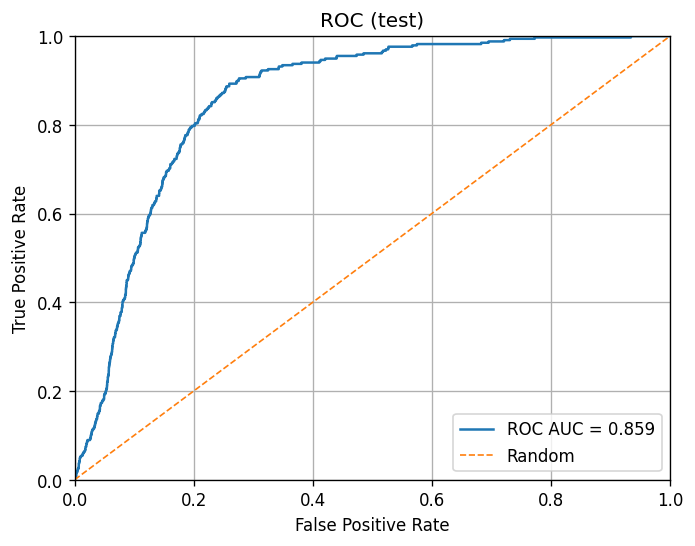

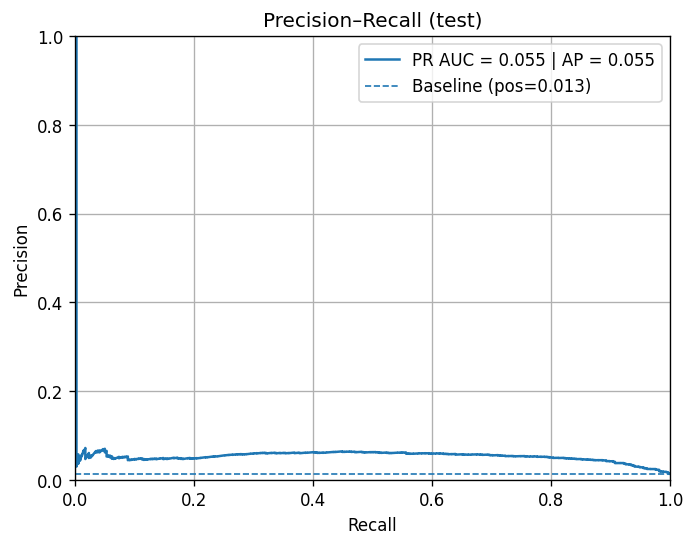

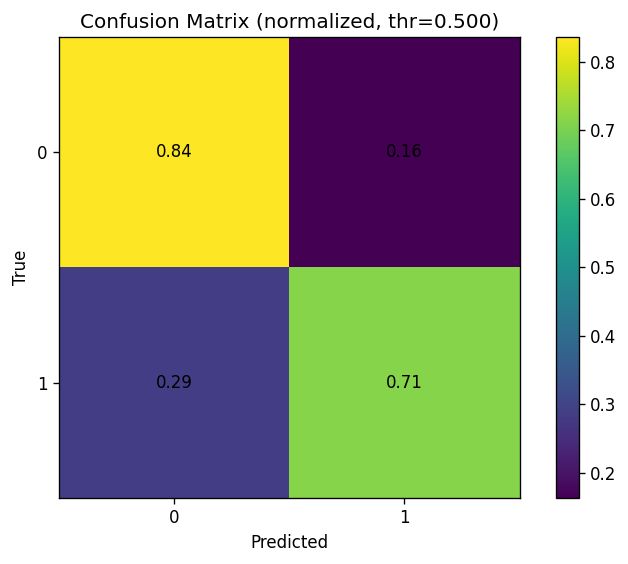

{'roc_auc_curve': 0.8590480953131716, 'pr_auc_curve': 0.05501900436574776, 'average_precision': 0.0554440608274986, 'threshold': 0.5, 'cm': [[21223, 4148], [96, 240]]}


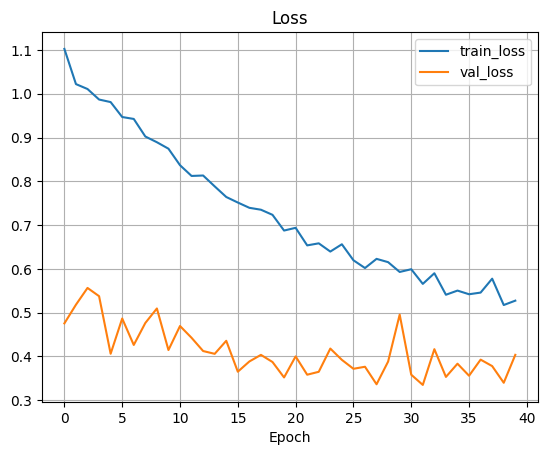

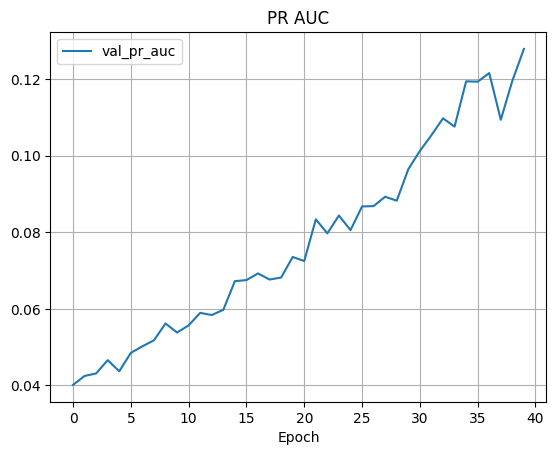

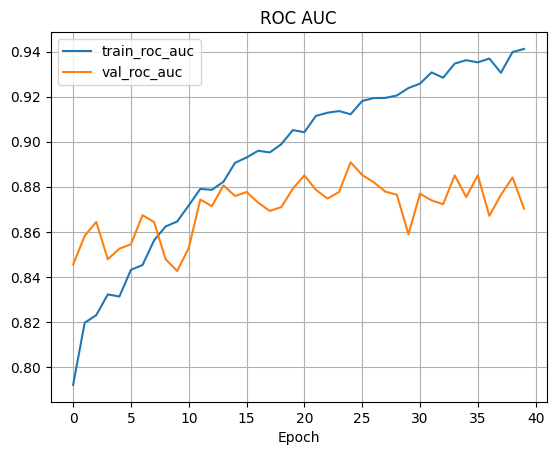

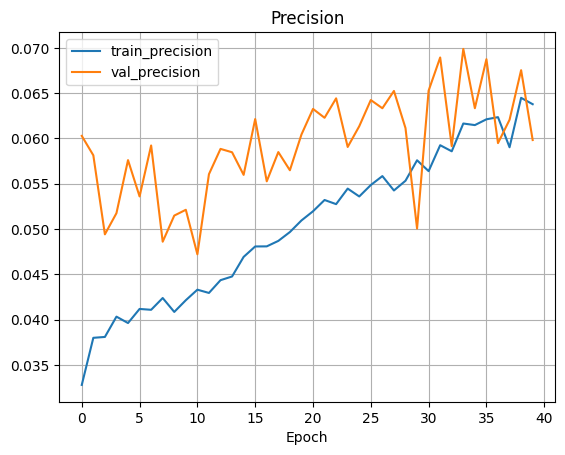

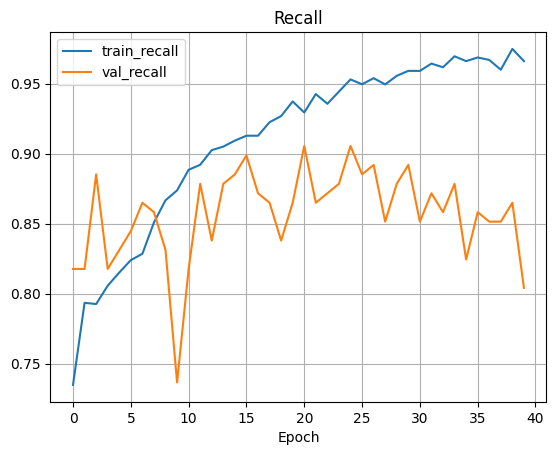

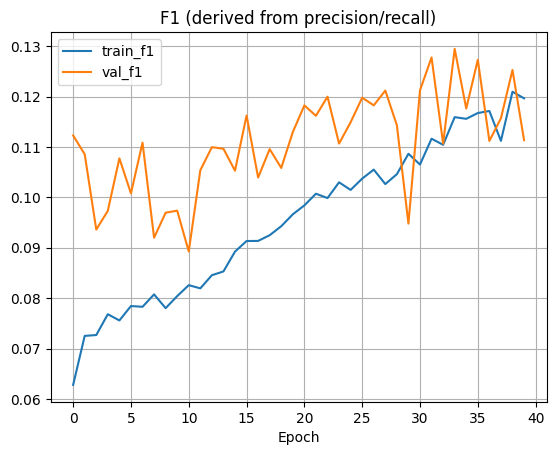

{'metrics': {'roc_auc': 0.8590480953131716,
  'pr_auc': 0.0554440608274986,
  'f1': 0.10160880609652836},
 'confusion_matrix': array([[21223,  4148],
        [   96,   240]], dtype=int64),
 'report': '              precision    recall  f1-score   support\n\n           0      0.995     0.837     0.909     25371\n           1      0.055     0.714     0.102       336\n\n    accuracy                          0.835     25707\n   macro avg      0.525     0.775     0.505     25707\nweighted avg      0.983     0.835     0.899     25707\n',
 'export': {'model_path': 'models\\lstm_dtc.keras.keras',
  'bundle_path': 'models\\scaler_dtc.npy',
  'manifest_path': 'models\\manifest.json'},
 'best_model_path': 'models\\lstm_dtc.keras.keras'}

In [11]:
cfg = DTC_Config.Config()
np.random.seed(cfg.seed)
tf.random.set_seed(cfg.seed)
train_and_eval(cfg) 